## 👉Step1 -> Importing all the libraries

In [1]:
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Model selection
from sklearn.model_selection import train_test_split

#Preprocessing
from sklearn.preprocessing import StandardScaler

#SMOTE to balance the dataset
from imblearn.over_sampling import SMOTE

#MODEL
from xgboost import XGBClassifier

#Anomaly detection
from sklearn.ensemble import IsolationForest

#Model calibration
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

#Model evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

#Model explainability
import shap

In [2]:
df = pd.read_csv("data/CreditCardData.csv")
df.shape

(284807, 31)

## Here we don't have categorical columns or NULL values

# Now we will do the EDA

## Class Distribution

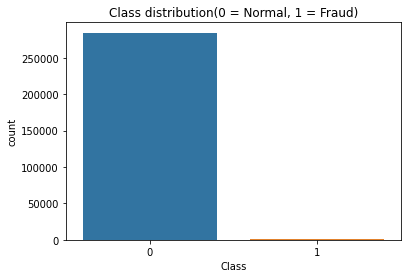

In [3]:
# Countplot will count the values present in class target
sns.countplot(x = "Class", data = df)
plt.title("Class distribution(0 = Normal, 1 = Fraud)")
plt.show()

In [4]:
#Percentage and instad of getting the count for each class normalize will convert it into percentage
fraud_percent = df['Class'].value_counts(normalize=True)*100
print(fraud_percent)

0    99.827251
1     0.172749
Name: Class, dtype: float64


## Amount Distribution
1. We saw that our data is highly right skewed because mostly the amount is lying within the range of 0-1000 so we can use log1p or sqrt to reduce the skewness

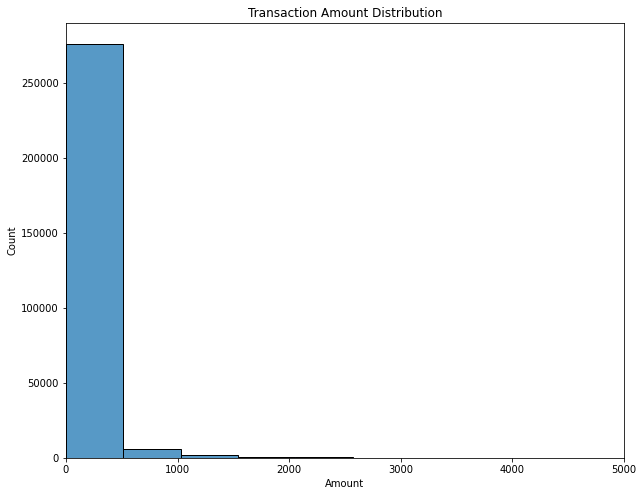

In [5]:
plt.figure(figsize=(10,8))
sns.histplot(df["Amount"], bins = 50)
plt.title("Transaction Amount Distribution")
plt.xlim(0,5000)
#plt.xscale("log")
plt.show()

## Now we will do the feature engineering
1. Creating new features
   
   EX-> As we know that the time is in seconds so we can convert it into hours

🧠 Explanation

Time is seconds → convert to hours
% 24 → simulate daily cycle

In [6]:
df["Hours"] = df["Time"]/3600

# Optional: Take modulo to map into 24-hour cycle
df['Hours'] = df['Hours'] % 24

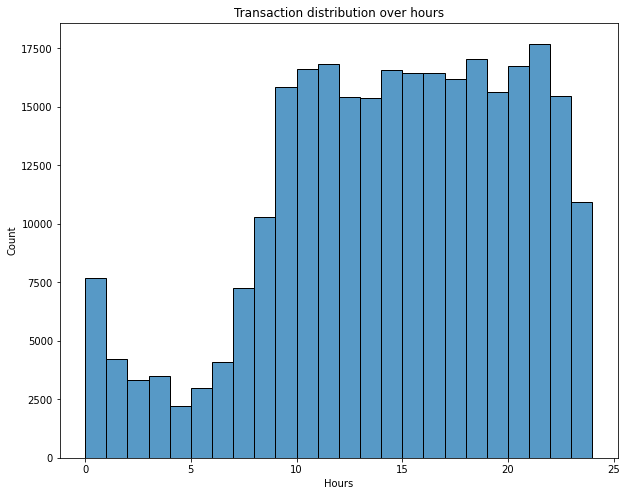

In [7]:
plt.figure(figsize=(10,8))
sns.histplot(df["Hours"], bins = 24)
plt.title("Transaction distribution over hours")
plt.show()

## Now since we have the time in hours we can drop time in seconds

In [8]:
df = df.drop("Time", axis = 1)

## Train-Test Split
1. Here we will use starified split which will make sure we had same proportion of classes in train and test as we have in our original dataset and we can check it because y_train.mean() approx = y_test.mean()

In [9]:
x = df.drop("Class", axis = 1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 42)

## Scaling Amount
1. Here we will have to make the copy of x_train and x_test because original x_train and x_test they are the view of the original dataframe otherwise we will get an error like this "A value is trying to be set on a copy of a slice from a DataFrame."
2. We will create a new feature as Amount_scaled

In [10]:
x_train = x_train.copy()
x_test = x_test.copy()
df["Class"].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [11]:
scaler = StandardScaler()

# Fit ONLY on training data
x_train.loc[:,"Amount_scaled"] = scaler.fit_transform(x_train[["Amount"]])

# Transform test data
x_test.loc[:,"Amount_scaled"] = scaler.transform(x_test[["Amount"]])

In [12]:
# Now we will drop the original Amount column from x_train and x_test
x_train = x_train.drop("Amount", axis = 1)
x_test = x_test.drop("Amount", axis = 1)

## Now we will handle the imbalanced Data(SMOTE + Class weight)
1. We apply SMOTE only on training data not on testing else it will lead to data leakage

### Before applying SMOTE distribution of class in y_train

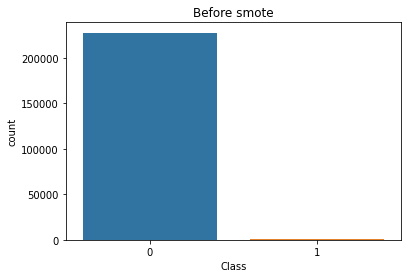

In [13]:
y_train.value_counts()

sns.countplot(x = y_train)
plt.title("Before smote")
plt.show()

In [14]:
# Now we will apply SMOTE
# smote = SMOTE(random_state = 42)

# x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [15]:
# sns.countplot(x = y_train_smote)
# plt.title("After smote")
# plt.show()

## Now we are going to build our model

In [16]:
model = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    scale_pos_weight = 1,
    max_depth = 5,
    random_state = 42,
    n_jobs = -1,
    use_label_encoder = False,
    eval_metric = "logloss",
    verbosity = 1
)

In [17]:
model.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_delta_step=0,
              max_depth=5, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=-1,
              num_parallel_tree=1, predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=1)

In [18]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

## BASELINE MODEL EVALUATION

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962


 Confusion Matrix


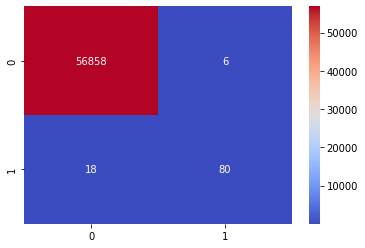


 Roc_Auc_Score 0.9748569447475107


In [19]:
print("Classification Report")
print(classification_report(y_test, y_pred))

print("\n Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = "d", cmap="coolwarm")
plt.show()

print("\n Roc_Auc_Score", roc_auc_score(y_test, y_prob))

In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
print(f"Length of precisions and recalls: {len(precisions)}, Length of thresholds: {len(thresholds)}")

Length of precisions and recalls: 25426, Length of thresholds: 25425


## PRECISION_RECALL_CURVE -> Len of pre and rec is 'n+1' but threshold len is 'n' so to align the dimension we say that drop the last point else when we will plot the graph we will get error that x and y must have same first dimension

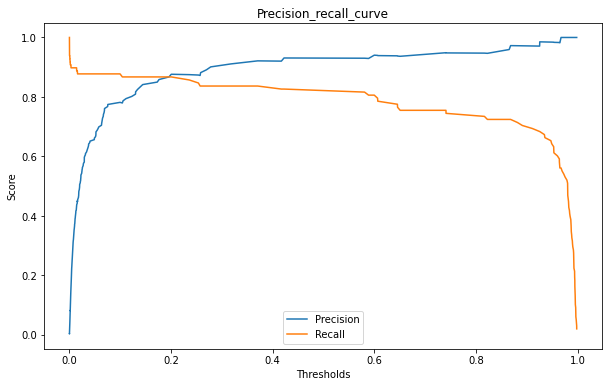

In [21]:
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], label ="Precision")
plt.plot(thresholds, recalls[:-1], label = "Recall")
plt.xlabel("Thresholds")
plt.ylabel("Score")
plt.title("Precision_recall_curve")
plt.legend()
plt.show()

## EVALUATION ON MULTIPLE THRESHOLDS

In [22]:
threhold_list = [0.1, 0.2, 0.3]

for t in threhold_list:
    y_new_pred = (y_prob>t).astype(int)

    print(f"\nThreshold: {t}")

    print(classification_report(y_test, y_new_pred))


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.87      0.82        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.87      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00   

## CONFUSION_MATRIX
### We saw that at 0.2 we got the best precision-recall trade off based on business requirement

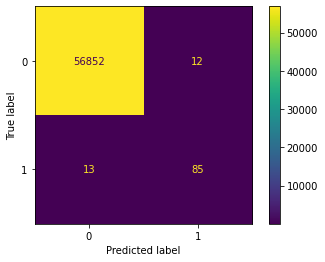

In [23]:
best_threshold = 0.2

y_pred2 = (y_prob>0.2).astype(int)

cm = confusion_matrix(y_test, y_pred2)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

## MODEL CALIBRATION
### We will check if the predicted probability is actually correct or not

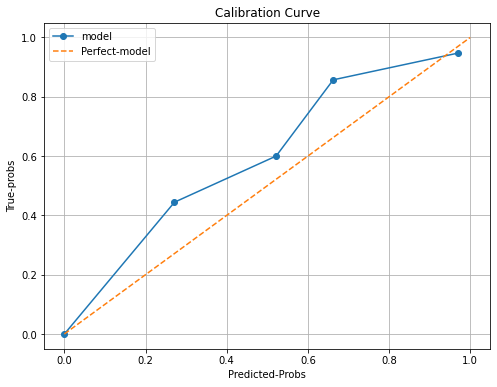

In [24]:
true_prob, pred_prob = calibration_curve(y_test, y_prob, n_bins = 5)

plt.figure(figsize = (8,6))
plt.plot(pred_prob, true_prob, marker = 'o', label = "model")
plt.plot([0,1], [0,1], linestyle = '--', label = "Perfect-model")

plt.xlabel("Predicted-Probs")
plt.ylabel("True-probs")
plt.title("Calibration Curve")
plt.grid()
plt.legend()
plt.show()

## CALIBRATED MODEL
### As we saw from the clibration curve that our model is mostly underconfident

In [25]:
calibrated_model = CalibratedClassifierCV(model, method = "isotonic", cv = 4)

calibrated_model.fit(x_train, y_train)

y_cal_prob = calibrated_model.predict_proba(x_test)[:,1]

In [26]:
y_cal_pred = (y_cal_prob>0.2).astype(int)

print(classification_report(y_test, y_cal_pred))
print(print("Calibrated ROC-AUC:", roc_auc_score(y_test, y_cal_prob)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.88      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Calibrated ROC-AUC: 0.9739054263376707
None


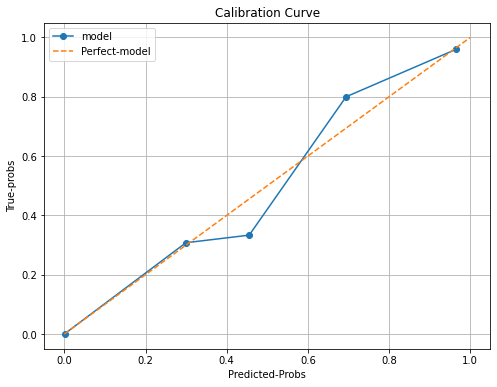

In [27]:
true_prob, pred_prob = calibration_curve(y_test, y_cal_prob, n_bins = 5)

plt.figure(figsize = (8,6))
plt.plot(pred_prob, true_prob, marker = 'o', label = "model")
plt.plot([0,1], [0,1], linestyle = '--', label = "Perfect-model")

plt.xlabel("Predicted-Probs")
plt.ylabel("True-probs")
plt.title("Calibration Curve")
plt.grid()
plt.legend()
plt.show()

# COST BASED EVALUATION

In [28]:
FP_Cost = 100
FN_Cost = 10000

In [29]:
# Cost function

def calculate_cost(y_test, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (fp*FP_Cost + fn*FN_Cost)

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Total Cost": total_cost
    }

In [30]:
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds_to_test:
    y_cost_pred = (y_cal_prob>=t).astype(int)

    metrics = calculate_cost(y_test, y_cost_pred)

    metrics["Threshold"] = t

    results.append(metrics)

cost_df = pd.DataFrame(results)

cost_df

,TN,FP,FN,TP,Total Cost,Threshold
0,56837,27,12,86,122700,0.1
1,56844,20,12,86,122000,0.2
2,56850,14,13,85,131400,0.3
3,56853,11,16,82,161100,0.4
4,56857,7,18,80,180700,0.5


## Visualize Cost vs Threshold

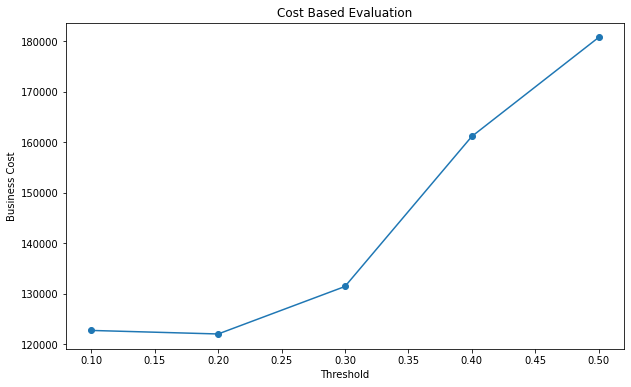

In [31]:
plt.figure(figsize = (10,6))

plt.plot(cost_df["Threshold"], cost_df["Total Cost"], marker = 'o')
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Cost Based Evaluation")
plt.show()

## Find Optimal Threshold

In [32]:
best_row = cost_df.loc[cost_df["Total Cost"].idxmin()]
print(best_row)

TN             56844.0
FP                20.0
FN                12.0
TP                86.0
Total Cost    122000.0
Threshold          0.2
Name: 1, dtype: float64


# Model Explainability with SHAP
1. This code creates a new DataFrame (x_sample) by randomly selecting 1,000 rows from the x_test DataFrame we are doing this for faster computation. The random_state=42 ensures the selection is reproducible, meaning it picks the exact same 1,000 rows every time the code runs.

## GLOBAL EXPLAINABILITY

In [33]:
explainer = shap.TreeExplainer(model)
x_sample = x_test.sample(1000, random_state=42)

In [34]:
shap_values = explainer.shap_values(x_sample)
shap_values[3]

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


array([ 4.1268881e-02, -1.2950498e-02,  9.3851060e-02,  2.6054260e-01,
        1.0719599e-02,  1.1470216e-02, -1.4323165e-01,  4.3705204e-03,
       -1.5841814e-02,  2.3447251e-02, -3.3854492e-02, -5.4522671e-02,
       -3.8257379e-02, -9.4093531e-01,  7.5389422e-02,  5.2279569e-02,
        1.6520360e-02, -6.8037890e-02, -1.2624539e-01, -7.7514961e-02,
       -4.3687969e-02, -4.1701436e-02, -5.1198597e-04, -4.4138692e-02,
       -3.8182650e-02,  5.7575200e-03,  1.6000735e-02, -3.6757682e-02,
        5.1811937e-02, -1.7470215e-01], dtype=float32)

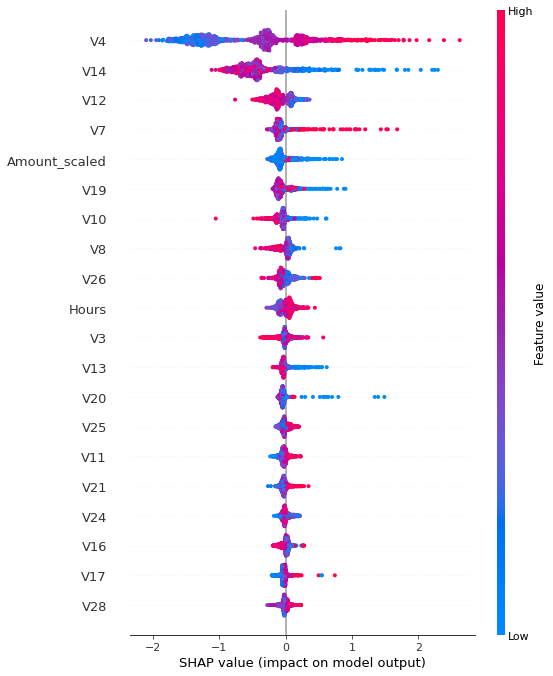

In [35]:
shap.summary_plot(shap_values, x_sample)

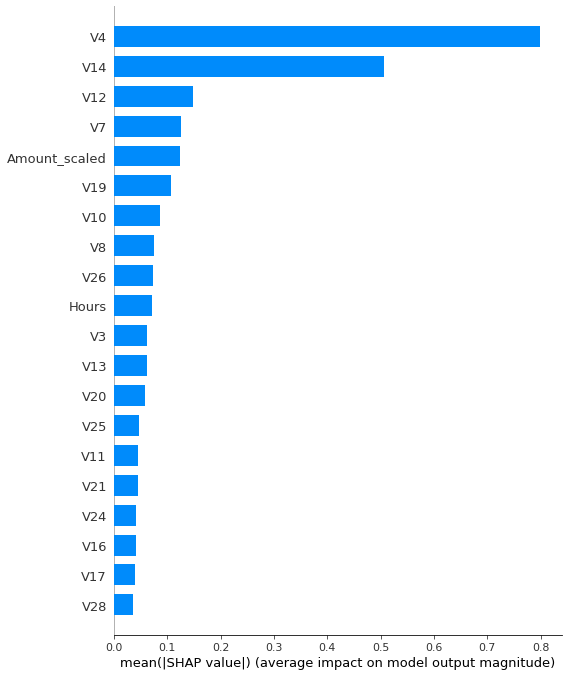

In [36]:
shap.summary_plot(shap_values, x_sample, plot_type="bar")

## LOCAL EXPLAINABILITY
Yes, we can directly use shap_values[0] with X_sample.iloc[0] as long as both correspond to the same row. The separate transaction approach is preferred when we want to explain a specific transaction, such as an actual fraud case.

## 🧠 Interpretation

This explains a single transaction.

Features pushing toward fraud:
positive SHAP values

Features pushing toward normal:
negative SHAP values

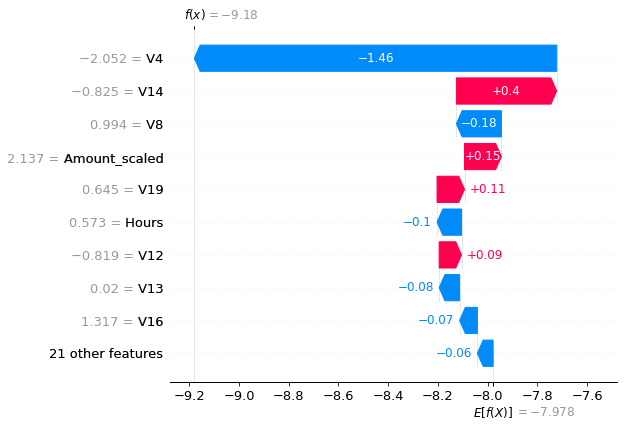

In [37]:
exp = shap.Explanation(
    values = shap_values[0],
    base_values = explainer.expected_value,
    data = x_sample.iloc[0],
    feature_names = x_sample.columns
)
# here we are using x_sample because we had fetched out the shap_values from x_sample and 
# If we use x_test then shap_values and x_test will corresponds to differenet row 
# So since we have fetched the shap_values from x_sample so we are using x_sample
# So that they can corresponds to same row

shap.plots.waterfall(exp)

## IMPORTANT 
1. shap_values will contain all the 1000 rows(1000,30)
2. Above we were explaining the first row it can be fraud or not
3. But if we want to explain about a transaction which is fraud then we will firstly fetch out the row which is fraud, so here we fetched transaction as fraud row

In [38]:
fraud_indices = y_test[y_test == 1].index

transaction = x_test.loc[[fraud_indices[0]]]
#  The double brackets ensure the result is returned as a pandas DataFrame (a subset with one row), rather than a pandas Series.

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


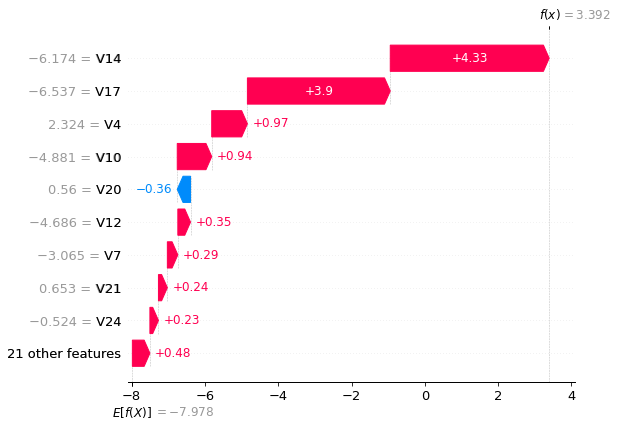

In [39]:
shap_values_single = explainer.shap_values(transaction)

exp = shap.Explanation(
    values=shap_values_single[0],# SHAP contribution of each feature
    base_values=explainer.expected_value, # Avg model output before seeing any features
    data=transaction.iloc[0], #Actual features values of the selected transaction
    feature_names=transaction.columns # Column names to display in the waterfall plot
)

shap.plots.waterfall(exp)

In [4]:
# Coverting the log odd output into probability
# Base prob is 0.034 = 0 % 
# Final value is 96.74% prob so it's a fraud transaction
from scipy.special import expit

base_prob = expit(-7.978)
final_prob = expit(3.392)

print(base_prob)
print(final_prob)

0.00034280702933674775
0.9674535779074295


# ANOMALY DETECTION 
### Using Isolation Forest -> Use Isolation Forest to detect unusual transactions and combine anomaly scores with a supervised fraud model.
1. We train Isolation Forest on legitimate transactions so that unusual behavior is detected as anomalies.

## Train Isolation Forest

In [40]:
iso_forest = IsolationForest(
    n_estimators = 200,
    contamination = 0.002,
    random_state = 42,
    n_jobs = -1
)


# Train on NORMAL transactions only
x_train_model = x_train[y_train==0]

iso_forest.fit(x_train_model)

IsolationForest(contamination=0.002, n_estimators=200, n_jobs=-1,
                random_state=42)

## Generate Anomaly Scores.
🧠 Interpretation

Original score_samples(): larger → more normal

Negating: larger → more suspicious

In [41]:
# Higher score = more normal
anomaly_score_train = iso_forest.score_samples(x_train)
anomaly_score_test = iso_forest.score_samples(x_test)

# Convert so higher value = more anomalous
x_train['AnomalyScore'] = -anomaly_score_train
x_test['AnomalyScore'] = -anomaly_score_test

## Visualize Anomaly Scores
#### Fraud transactions should generally have higher anomaly scores than normal transactions.

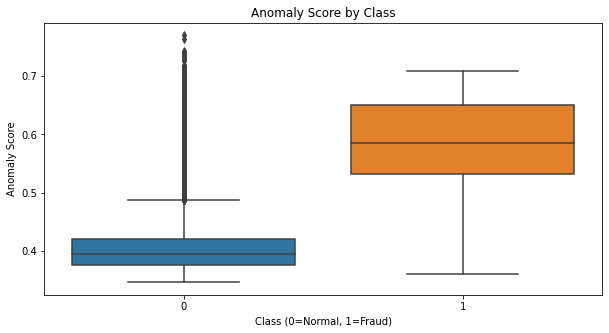

In [42]:
plt.figure(figsize=(10,5))

sns.boxplot(x = y_test, y = x_test["AnomalyScore"])
plt.title("Anomaly Score by Class")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Anomaly Score")
plt.show()

## Retrain XGBoost with Anomaly Score

In [43]:
hybrid_model = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    scale_pos_weight = (y_train==0).sum()/ (y_train==1).sum(),
    random_state = 42,
    n_jobs = -1,
    use_label_encoder = False,
    eval_metric = "logloss"
)

In [44]:
hybrid_model.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_delta_step=0,
              max_depth=5, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=-1,
              num_parallel_tree=1, predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=577.2868020304569,
              subsample=1, tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [45]:
y_hybrid_prob = hybrid_model.predict_proba(x_test)[:,1]

In [46]:
print("Hybrid ROC-AUC:", roc_auc_score(y_test, y_hybrid_prob))

Hybrid ROC-AUC: 0.9771502790761775


In [47]:
y_hybrid_pred = (y_hybrid_prob>0.2).astype(int)

In [48]:
print(classification_report(y_test, y_hybrid_pred))
print(confusion_matrix(y_test, y_hybrid_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.89      0.41        98

    accuracy                           1.00     56962
   macro avg       0.63      0.94      0.71     56962
weighted avg       1.00      1.00      1.00     56962

[[56627   237]
 [   11    87]]


In [49]:
print((y_train==0).sum()/ (y_train==1).sum())

577.2868020304569


### I experimented with an Isolation Forest anomaly score as an additional feature. Although ROC-AUC improved slightly, cost-based evaluation showed that false positives increased significantly, leading to higher total business loss. Therefore, I selected the calibrated XGBoost model without anomaly features for deployment.

# LAST STEP -> We will make this model production ready by saving the artifacts, organizing code, and defining monitoring metrics

## 📦 Step 1 — Save Model Artifacts

In [50]:
import joblib

In [51]:
joblib.dump(calibrated_model, "models/fraud_model.pkl")

joblib.dump(scaler, "models/amount_scaler.pkl")

joblib.dump(best_threshold, "models/best_threshold.pkl")

joblib.dump(list(x_train.columns), "models/feature_names.pkl")

['models/feature_names.pkl']

0.00034280702933674775
0.9807913679466901
